# Module 1 Homework - Introduction and Data Sources (2026 cohort)

Stock Markets Analytics Zoomcamp · [homework1.md](https://github.com/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/cohorts/2026/homework1.md)

Notebook version of `homework1_solution.py` - same calculations, split per question, with the
intermediate tables and a few charts kept visible. Written answers live in `solution.md`.

| # | Question | Deliverable |
|---|----------|-------------|
| 1 | S&P 500 additions since 2020 | Year with the most additions |
| 2 | World indexes YTD to 2026-08-21 | How many of 10 beat the S&P 500 |
| 3 | S&P 500 corrections since 1950 | Median drawdown, % |
| 4 | AMZN earnings surprises | Median 2-day return after a positive surprise |
| 5-6 | Capstone idea, extra metrics | Free text |

Data are live: Wikipedia and Yahoo Finance revise their histories, so re-running can shift the printed
values slightly. Q3 intentionally excludes the still-unfinished correction.

In [1]:
# !pip install -q yfinance pandas matplotlib lxml html5lib beautifulsoup4

In [2]:
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
import requests
import yfinance as yf

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
INDEXES = {
    "United States (S&P 500)": "^GSPC",
    "China (Shanghai Composite)": "000001.SS",
    "Hong Kong (Hang Seng)": "^HSI",
    "Australia (S&P/ASX 200)": "^AXJO",
    "India (Nifty 50)": "^NSEI",
    "Canada (S&P/TSX Composite)": "^GSPTSE",
    "Germany (DAX)": "^GDAXI",
    "United Kingdom (FTSE 100)": "^FTSE",
    "Japan (Nikkei 225)": "^N225",
    "Mexico (IPC Mexico)": "^MXX",
    "Brazil (Ibovespa)": "^BVSP",
}

print("pandas", pd.__version__, "| yfinance", yf.__version__)

pandas 3.0.5 | yfinance 1.7.0


In [3]:
def close_history(symbol: str, start: str, end: str | None = None) -> pd.Series:
    """Return a named, timezone-naive Close series; `end` is Yahoo-exclusive."""
    frame = yf.Ticker(symbol).history(start=start, end=end, auto_adjust=False)
    if frame.empty:
        raise RuntimeError(f"No Yahoo Finance data returned for {symbol}")
    series = frame["Close"].copy()
    series.index = pd.to_datetime(series.index).tz_localize(None)
    return series

---
## Question 1 - [Index] S&P 500 stocks added to the index

**Which year had the highest number of additions, starting from 2020?**

Wikipedia's constituent table carries a `Date added` column, so the answer is a `read_html` plus a
`groupby`. `read_html`'s default User-Agent gets blocked, hence the explicit header.

In [4]:
response = requests.get(WIKI_URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
response.raise_for_status()

constituents = pd.read_html(StringIO(response.text))[0]
additions = constituents[["Symbol", "Security", "Date added"]].copy()
additions["year_added"] = pd.to_datetime(additions["Date added"], errors="coerce").dt.year

print("constituents:", len(additions))
additions.head()

constituents: 503


,Symbol,Security,Date added,year_added
0,MMM,3M,1957-03-04,1957
1,AOS,A. O. Smith,2017-07-26,2017
2,ABT,Abbott Laboratories,1957-03-04,1957
3,ABBV,AbbVie,2012-12-31,2012
4,ACN,Accenture,2011-07-06,2011


In [5]:
counts = additions[additions.year_added.ge(2020)].groupby("year_added").size()

print("Q1 additions by year (2020+):")
print(counts.to_string())

q1_year = int(counts.idxmax())
q1_count = int(counts.max())
print()
print("ANSWER Q1")
print(f"  Year with the most additions : {q1_year}  ({q1_count} additions)")
print("  (the current year is incomplete - read the answer off completed years)")

Q1 additions by year (2020+):
year_added
2020    10
2021    10
2022    15
2023    15
2024    16
2025    18
2026    13

ANSWER Q1
  Year with the most additions : 2025  (18 additions)
  (the current year is incomplete - read the answer off completed years)


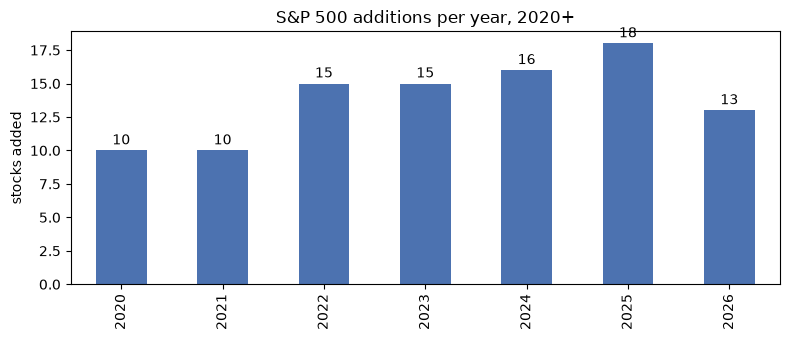

In [6]:
ax = counts.plot(kind="bar", figsize=(8, 3.5), color="#4C72B0")
ax.set_xlabel("")
ax.set_ylabel("stocks added")
ax.set_title("S&P 500 additions per year, 2020+")
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.tight_layout()
plt.show()

In [7]:
# Additional question: how many current constituents joined more than 20 years ago?
age_days = (pd.Timestamp.today().normalize() - pd.to_datetime(additions["Date added"])).dt.days
old_members = int(age_days.gt(20 * 365.25).sum())

print("Q1 additional - current constituents added >20 years ago:", old_members)

Q1 additional - current constituents added >20 years ago: 224


---
## Question 2 - [Macro] Indexes YTD as of 2026-08-21

**How many of the 10 non-US indexes beat the S&P 500 year to date?**

YTD growth = last close on/before 2026-08-21 divided by the first close of 2026, minus 1.
`2026-08-22` as the `end` is deliberate: Yahoo's `end` is exclusive, so this includes the 21 August close.
Currency conversion is ignored, per the assignment.

In [8]:
ytd = {}
for name, symbol in INDEXES.items():
    close = close_history(symbol, "2026-01-01", "2026-08-22")
    ytd[name] = close.iloc[-1] / close.iloc[0] - 1
    print(f"  {name:32s} {close.index[0].date()} -> {close.index[-1].date()}  {ytd[name]*100:+7.2f}%")

returns = pd.Series(ytd, name="YTD return").sort_values(ascending=False)

  United States (S&P 500)          2026-01-02 -> 2026-08-21   +11.90%
  China (Shanghai Composite)       2026-01-05 -> 2026-08-21    -2.94%
  Hong Kong (Hang Seng)            2026-01-02 -> 2026-08-21    -1.25%
  Australia (S&P/ASX 200)          2026-01-02 -> 2026-08-21    +3.79%
  India (Nifty 50)                 2026-01-01 -> 2026-08-21    -7.25%
  Canada (S&P/TSX Composite)       2026-01-02 -> 2026-08-21   +14.86%
  Germany (DAX)                    2026-01-02 -> 2026-08-21    +6.51%
  United Kingdom (FTSE 100)        2026-01-02 -> 2026-08-21    +8.70%
  Japan (Nikkei 225)               2026-01-05 -> 2026-08-21   +27.36%
  Mexico (IPC Mexico)              2026-01-02 -> 2026-08-21    +2.48%
  Brazil (Ibovespa)                2026-01-02 -> 2026-08-21    +6.54%


In [9]:
us_return = returns["United States (S&P 500)"]
q2_better = int((returns.drop("United States (S&P 500)") > us_return).sum())

print("Q2 YTD returns through 2026-08-21 (%):")
print((returns * 100).round(2).to_string())
print()
print("ANSWER Q2")
print(f"  S&P 500 YTD                : {us_return*100:+.2f}%")
print(f"  Indexes better than the US : {q2_better} of 10")

Q2 YTD returns through 2026-08-21 (%):
Japan (Nikkei 225)            27.36
Canada (S&P/TSX Composite)    14.86
United States (S&P 500)       11.90
United Kingdom (FTSE 100)      8.70
Brazil (Ibovespa)              6.54
Germany (DAX)                  6.51
Australia (S&P/ASX 200)        3.79
Mexico (IPC Mexico)            2.48
Hong Kong (Hang Seng)         -1.25
China (Shanghai Composite)    -2.94
India (Nifty 50)              -7.25

ANSWER Q2
  S&P 500 YTD                : +11.90%
  Indexes better than the US : 2 of 10


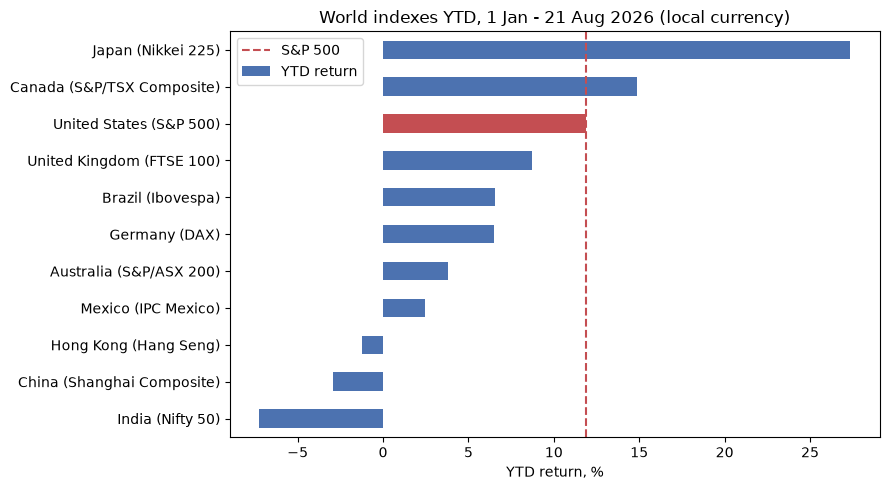

In [10]:
colors = ["#C44E52" if name == "United States (S&P 500)" else "#4C72B0"
          for name in returns.sort_values().index]

ax = (returns.sort_values() * 100).plot(kind="barh", figsize=(9, 5), color=colors)
ax.axvline(us_return * 100, color="#C44E52", linestyle="--", label="S&P 500")
ax.set_xlabel("YTD return, %")
ax.set_title("World indexes YTD, 1 Jan - 21 Aug 2026 (local currency)")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Additional question: same comparison over 3, 5 and 10 years
end = pd.Timestamp("2026-08-22")
longer_horizons = {}

for years in (3, 5, 10):
    period_returns = {}
    for name, symbol in INDEXES.items():
        close = close_history(symbol, f"{2026 - years}-08-21", end.strftime("%Y-%m-%d"))
        period_returns[name] = close.iloc[-1] / close.iloc[0] - 1
    period_returns = pd.Series(period_returns)
    longer_horizons[f"{years}y"] = period_returns
    better = int((period_returns.drop("United States (S&P 500)")
                  > period_returns["United States (S&P 500)"]).sum())
    print(f"Q2 additional - {years:2d}-year return leaders vs US: {better} of 10")

pd.DataFrame(longer_horizons).mul(100).round(2)

Q2 additional -  3-year return leaders vs US: 2 of 10
Q2 additional -  5-year return leaders vs US: 2 of 10
Q2 additional - 10-year return leaders vs US: 1 of 10


,3y,5y,10y
United States (S&P 500),74.43,71.32,251.61
China (Shanghai Composite),26.26,12.31,26.59
Hong Kong (Hang Seng),47.59,3.58,13.09
Australia (S&P/ASX 200),27.31,20.95,64.26
India (Nifty 50),25.05,47.01,181.05
Canada (S&P/TSX Composite),85.09,78.83,148.30
Germany (DAX),67.51,64.87,149.05
United Kingdom (FTSE 100),49.03,52.15,58.40
Japan (Nikkei 225),109.14,140.11,297.73
Mexico (IPC Mexico),23.76,26.27,36.10


---
## Question 3 - [Index] S&P 500 market corrections

**What is the median drawdown of corrections of at least 5%?**

Method:

1. Daily closes from 1950.
2. All-time highs = days whose close exceeds every previous close (`close > close.cummax().shift(1)`).
3. Between each consecutive pair of ATHs, find the trough (excluding the next ATH itself).
4. Drawdown = `(high - low) / high * 100`; keep everything at 5% or more.
5. Duration = calendar days from peak to trough.

Pairing each record with the next follows the homework's definition exactly. A side effect: any
correction still underway at the last data point has no closing ATH, so it is excluded.

In [12]:
close = close_history("^GSPC", "1950-01-01")
print(f"daily closes: {len(close):,} from {close.index[0].date()} to {close.index[-1].date()}")

ath = close[close > close.cummax().shift(1)]
print(f"all-time highs: {len(ath):,}")

daily closes: 19,297 from 1950-01-03 to 2026-09-15
all-time highs: 1,509


In [13]:
corrections: list[dict[str, object]] = []

for high_date, next_high_date in zip(ath.index[:-1], ath.index[1:]):
    trough = close.loc[high_date:next_high_date].iloc[:-1]
    low_date, low = trough.idxmin(), trough.min()
    high = close.loc[high_date]
    drawdown = (high - low) / high * 100
    if drawdown >= 5:
        corrections.append({
            "peak": high_date,
            "trough": low_date,
            "drawdown_pct": drawdown,
            "duration_days": (low_date - high_date).days,
        })

result = pd.DataFrame(corrections)
print(f"corrections of 5%+ since 1950: {len(result)}")
result.tail()

corrections of 5%+ since 1950: 74


,peak,trough,drawdown_pct,duration_days
69,2024-03-28,2024-04-19,5.464427,22
70,2024-07-16,2024-08-05,8.485144,20
71,2025-02-19,2025-04-08,18.902206,48
72,2025-10-28,2025-11-20,5.110085,23
73,2026-01-27,2026-03-30,9.097525,62


In [14]:
print("Q3 correction percentiles (25%, median, 75%):")
print(result[["drawdown_pct", "duration_days"]].quantile([.25, .50, .75]).round(2))

q3_median_drawdown = round(result.drawdown_pct.median(), 2)
print()
print("ANSWER Q3")
print(f"  Median drawdown : {q3_median_drawdown}%")
print(f"  Median duration : {result.duration_days.median():.0f} days")

Q3 correction percentiles (25%, median, 75%):
      drawdown_pct  duration_days
0.25          6.23          22.00
0.50          7.99          40.50
0.75         14.02          86.25

ANSWER Q3
  Median drawdown : 7.99%
  Median duration : 40 days


In [15]:
# Cross-check against the top-10 list given in the homework
print("Q3 top 10 drawdowns:")
print(
    result.nlargest(10, "drawdown_pct")
    .assign(peak=lambda d: d["peak"].dt.date, trough=lambda d: d["trough"].dt.date)
    .to_string(index=False)
)

Q3 top 10 drawdowns:
      peak     trough  drawdown_pct  duration_days
2007-10-09 2009-03-09     56.775388            517
2000-03-24 2002-10-09     49.146948            929
1973-01-11 1974-10-03     48.203593            630
1968-11-29 1970-05-26     36.061641            543
2020-02-19 2020-03-23     33.924960             33
1987-08-25 1987-12-04     33.509515            101
1961-12-12 1962-06-26     27.973568            196
1980-11-28 1982-08-12     27.113582            622
2022-01-03 2022-10-12     25.425097            282
1966-02-09 1966-10-07     22.177335            240


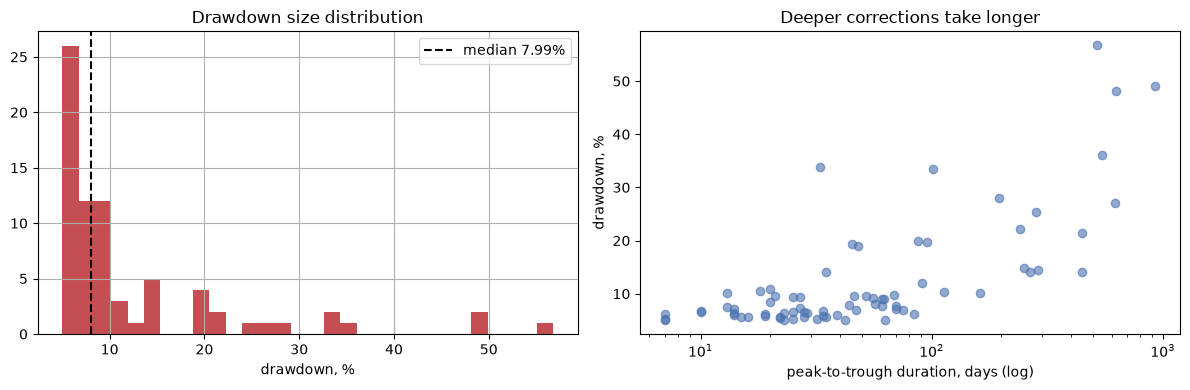

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

result["drawdown_pct"].hist(bins=30, ax=axes[0], color="#C44E52")
axes[0].axvline(q3_median_drawdown, color="black", linestyle="--",
                label=f"median {q3_median_drawdown}%")
axes[0].set_title("Drawdown size distribution")
axes[0].set_xlabel("drawdown, %")
axes[0].legend()

axes[1].scatter(result["duration_days"], result["drawdown_pct"], alpha=0.6, color="#4C72B0")
axes[1].set_xscale("log")
axes[1].set_xlabel("peak-to-trough duration, days (log)")
axes[1].set_ylabel("drawdown, %")
axes[1].set_title("Deeper corrections take longer")

plt.tight_layout()
plt.show()

---
## Question 4 - [Stocks] Earnings surprise analysis for AMZN

**What is the median 2-day return following a positive earnings surprise?**

`get_earnings_dates(limit=25)` returns the assignment's sample: one future event plus the 24 reported
events starting 2020-10-29. The future row has no `Reported EPS` / `Surprise(%)` and is dropped.

For each announcement the calendar date is mapped to its next trading session with `searchsorted`,
then the 2-day return is `Close[t+1] / Close[t-1] - 1` across the three consecutive trading days.

In [17]:
amzn = yf.Ticker("AMZN")

earnings = amzn.get_earnings_dates(limit=25)
earnings.index = pd.to_datetime(earnings.index).tz_localize(None).normalize()

print(f"rows returned: {len(earnings)} (one is a future date with no reported figures)")
earnings.tail()

rows returned: 25 (one is a future date with no reported figures)


,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2021-10-28,0.44,0.31,-30.85
2021-07-29,0.62,0.76,22.57
2021-04-29,0.48,0.79,64.11
2021-02-02,0.36,0.70,97.39
2020-10-29,0.37,0.62,66.17


In [18]:
earnings = earnings.dropna(subset=["Reported EPS", "Surprise(%)"])
prices = close_history("AMZN", "2020-01-01")

print(f"reported earnings events: {len(earnings)} from {earnings.index.min().date()}")
print(f"price rows: {len(prices):,}")

reported earnings events: 24 from 2020-10-29
price rows: 1,684


In [19]:
rows = []
for announced, row in earnings.iterrows():
    position = prices.index.searchsorted(announced)
    if position == len(prices) or position == 0 or position + 1 >= len(prices):
        continue
    two_day_return = prices.iloc[position + 1] / prices.iloc[position - 1] - 1
    rows.append({
        "announcement": announced,
        "surprise_pct": row["Surprise(%)"],
        "two_day_return": two_day_return,
    })

result_q4 = pd.DataFrame(rows)
positive = result_q4[result_q4.surprise_pct > 0]

print("Q4 observations used:", len(result_q4), "; positive surprises:", len(positive))
result_q4.to_string(index=False)

Q4 observations used: 24 ; positive surprises: 20


'announcement  surprise_pct  two_day_return\n  2026-07-30        215.02        0.198235\n  2026-04-29         68.18        0.020639\n  2026-02-05          0.22       -0.097300\n  2025-10-30         25.20        0.060443\n  2025-07-31         26.13       -0.067075\n  2025-05-01         17.08        0.030149\n  2025-02-06         25.36       -0.029724\n  2024-10-31         25.17        0.026981\n  2024-08-01         23.76       -0.102043\n  2024-04-30         17.67       -0.010831\n  2024-02-01         24.38        0.107023\n  2023-10-26         62.22        0.052311\n  2023-08-03         91.19        0.088605\n  2023-04-27         46.82        0.004477\n  2023-02-02        -81.68       -0.016738\n  2022-10-27         33.00       -0.105914\n  2022-07-28       -273.30        0.115566\n  2022-04-28       -191.55       -0.100498\n  2022-02-03        641.94        0.046656\n  2021-10-28        -30.85       -0.005913\n  2021-07-29         22.57       -0.083389\n  2021-04-29         64.11     

In [20]:
q4_median_return = round(positive.two_day_return.median() * 100, 2)
q4_corr = round(result_q4[["surprise_pct", "two_day_return"]].corr().iloc[0, 1], 4)

print("ANSWER Q4")
print(f"  Median 2-day return after positive surprises : {q4_median_return}%")
print()
print(f"  Correlation (surprise % vs 2-day return)     : {q4_corr}")

ANSWER Q4
  Median 2-day return after positive surprises : 0.35%

  Correlation (surprise % vs 2-day return)     : 0.2217


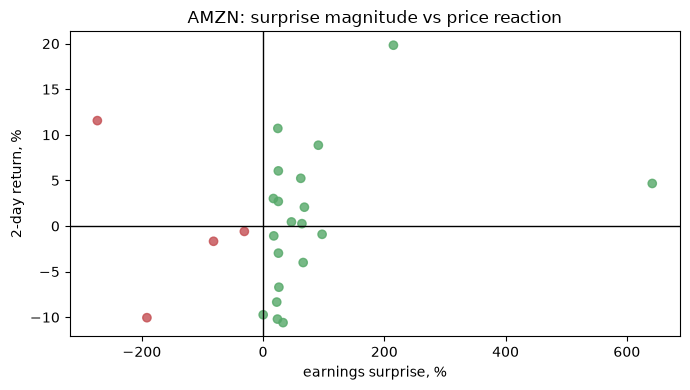

In [21]:
plt.figure(figsize=(7, 4))
plt.scatter(result_q4["surprise_pct"], result_q4["two_day_return"] * 100,
            c=["#55A868" if s > 0 else "#C44E52" for s in result_q4["surprise_pct"]], alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("earnings surprise, %")
plt.ylabel("2-day return, %")
plt.title("AMZN: surprise magnitude vs price reaction")
plt.tight_layout()
plt.show()

---
## Questions 5 and 6 - [Exploratory, optional]

**Q5.** Capstone project idea - free text: which market, which asset class, which horizon, which features.

**Q6.** Extra metrics worth pulling in, and why. Candidates and where they come from:

| Metric | Source | Why it might help |
|---|---|---|
| VIX (`^VIX`) | yfinance | Regime filter - strategies behave differently above/below VIX 20 |
| 10Y yield (`^TNX`), 10Y-2Y spread | yfinance / FRED | Discount-rate driver; the spread leads recessions |
| CPI, unemployment, Fed funds | FRED (`pandas_datareader`) | Macro regime features for monthly models |
| DXY (`DX-Y.NYB`), oil (`CL=F`), gold (`GC=F`) | yfinance | Cross-asset context, especially for non-US markets |
| Sector ETF relative strength (XLK, XLE, ...) | yfinance | Rotation signal, cheaper than single-name breadth |

Written answers for both go in `solution.md`.

---
## Answer summary

In [22]:
print("=" * 58)
print("MODULE 1 HOMEWORK - ANSWERS")
print("=" * 58)
print(f"Q1  Year with most S&P 500 additions : {q1_year} ({q1_count})")
print(f"Q2  Indexes beating the S&P 500 YTD  : {q2_better} of 10")
print(f"Q3  Median correction drawdown       : {q3_median_drawdown}%")
print(f"Q4  Median 2-day post-surprise return: {q4_median_return}%")
print("Q5-Q6  Free text - see solution.md")
print("=" * 58)

MODULE 1 HOMEWORK - ANSWERS
Q1  Year with most S&P 500 additions : 2025 (18)
Q2  Indexes beating the S&P 500 YTD  : 2 of 10
Q3  Median correction drawdown       : 7.99%
Q4  Median 2-day post-surprise return: 0.35%
Q5-Q6  Free text - see solution.md
